In [1]:
import pandas as pd
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data_path = Path("../data/processed/processed_news.csv")

df = pd.read_csv(data_path)

print(df.shape)
df.head()

(38653, 2)


,content,label
0,ben stein call th circuit court committed ‘cou...,1
1,trump drop steve bannon national security coun...,0
2,puerto rico expects u lift jones act shipping ...,0
3,oops trump accidentally confirmed leaked israe...,1
4,donald trump head scotland reopen golf resort ...,0


In [3]:
X = df["content"]
y = df["label"]

## Train-Validation-Test Split

The dataset is divided into training (70%), validation (10%), and testing (20%) sets using stratified sampling to maintain the class distribution.

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

## TF-IDF Vectorization

The text data is converted into numerical feature vectors using TF-IDF. The vectorizer is fitted only on the training set to prevent data leakage.

In [5]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train = vectorizer.fit_transform(X_train)

X_val = vectorizer.transform(X_val)

X_test = vectorizer.transform(X_test)

## Define Machine Learning Models

Three commonly used machine learning algorithms are selected for comparison. Each model is trained on the same training data and evaluated using the validation set to identify the best-performing classifier.

In [6]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Linear SVM": LinearSVC(
        random_state=42
    )
}

## Train and Compare Models

Each model is trained on the training set and evaluated on the validation set. The performance is compared using Accuracy, Precision, Recall, and F1-score.

In [7]:
results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict on validation data
    y_pred = model.predict(X_val)

    # Store evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred)
    })

## Model Comparison

The validation performance of all models is summarized below to identify the most suitable classifier for the fake news detection task.

In [8]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.994568,0.994836,0.993127,0.993981
1,Logistic Regression,0.988101,0.991898,0.981672,0.986759
2,Multinomial Naive Bayes,0.956803,0.953997,0.950172,0.952080


## Select Best Model

The model with the highest validation F1-score is selected for final evaluation on the test dataset.

In [9]:
best_model_name = results_df.loc[0, "Model"]

print(f"Best Model: {best_model_name}")

Best Model: Linear SVM


In [10]:
best_model = models[best_model_name]

In [11]:
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.9946,0.9948,0.9931,0.9940
1,Logistic Regression,0.9881,0.9919,0.9817,0.9868
2,Multinomial Naive Bayes,0.9568,0.9540,0.9502,0.9521


## Evaluate the Best Model

The best-performing model selected from the validation set is evaluated on the unseen test set to measure its generalization performance.

In [12]:
# Predict on test data

y_test_pred = best_model.predict(X_test)

# Calculate evaluation metrics

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Accuracy : 0.9953
Precision: 0.9974
Recall   : 0.9923
F1 Score : 0.9948


## Classification Report

The classification report provides Precision, Recall, F1-score, and Support for each class, giving a detailed view of model performance.

In [13]:
from sklearn.metrics import classification_report

In [14]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4239
           1       1.00      0.99      0.99      3492

    accuracy                           1.00      7731
   macro avg       1.00      1.00      1.00      7731
weighted avg       1.00      1.00      1.00      7731



## Confusion Matrix

The confusion matrix summarizes the number of correct and incorrect predictions made by the model for each class.

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

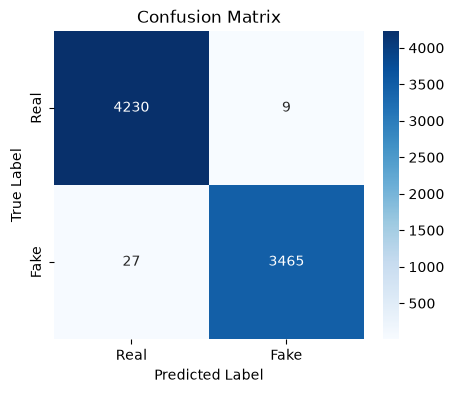

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## Save the Best Model

The trained model is saved so that it can be reused later for prediction without retraining.

In [17]:
artifact_path = Path("../artifacts")
artifact_path.mkdir(exist_ok=True)

joblib.dump(best_model, artifact_path / "best_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


In [18]:
print("Model Exists      :", (artifact_path / "best_model.pkl").exists())
print("Vectorizer Exists :", (artifact_path / "tfidf_vectorizer.pkl").exists())

Model Exists      : True
Vectorizer Exists : True
